# 🏠 House Price Prediction System
## AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship Program 2026 | BharatCares

**Student Name:** Vinayak Rathi  
**Domain:** Machine Learning & Data Analytics  
**Dataset:** `house_price_regression_dataset.csv`  
**Algorithm:** Linear Regression  
**Deployment Stack:** Flask REST API & Streamlit Interactive Dashboard  

---

### 1. Project Introduction & Problem Statement
Real estate valuation is a critical process for home buyers, sellers, property investors, and financial lenders. Traditional manual appraisal methods rely heavily on subjective judgment, which can introduce inconsistency and valuation bias.

### 2. Business Objective
The objective of this project is to construct a fully transparent Machine Learning pipeline that predicts property prices (`House_Price`) based on property dimensions, age, lot size, and location quality using **Linear Regression**. The model is encapsulated in a scikit-learn Pipeline, exposed via a **Flask REST API**, and presented through an interactive **Streamlit Dashboard**.

### 3. Dataset Description
The project utilizes `house_price_regression_dataset.csv` containing 1,000 property records with 7 predictive features and 1 target variable (`House_Price`):
- `Square_Footage`: Living area of the house in square feet (503 - 4,999 sq.ft.)
- `Num_Bedrooms`: Total number of bedrooms (1 - 5)
- `Num_Bathrooms`: Total number of bathrooms (1 - 3)
- `Year_Built`: Year of construction (1950 - 2020)
- `Lot_Size`: Total lot size in acres (0.5 - 5.0 acres)
- `Garage_Size`: Number of garage parking spaces (0 - 2 cars)
- `Neighborhood_Quality`: Rating of neighborhood quality (1 - 10 scale)
- `House_Price`: Final property transaction price ($111,626 - $1,108,237)

In [1]:
# Section 5: Import Libraries
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("[*] Libraries imported successfully.")

[*] Libraries imported successfully.


In [2]:
# Section 6 & 7: Load Dataset & Data Understanding
data_path = "house_price_regression_dataset.csv"
if not os.path.exists(data_path):
    data_path = os.path.join("data", "house_prices.csv")

df = pd.read_csv(data_path)
print(f"[*] Dataset Shape: {df.shape}")
display(df.head())
print("\n[*] Dataset Info:")
df.info()
print("\n[*] Descriptive Statistics:")
display(df.describe())

[*] Dataset Shape: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



[*] Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

[*] Descriptive Statistics:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


[*] Missing Values Count per Feature:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

[*] Total Duplicate Rows: 0


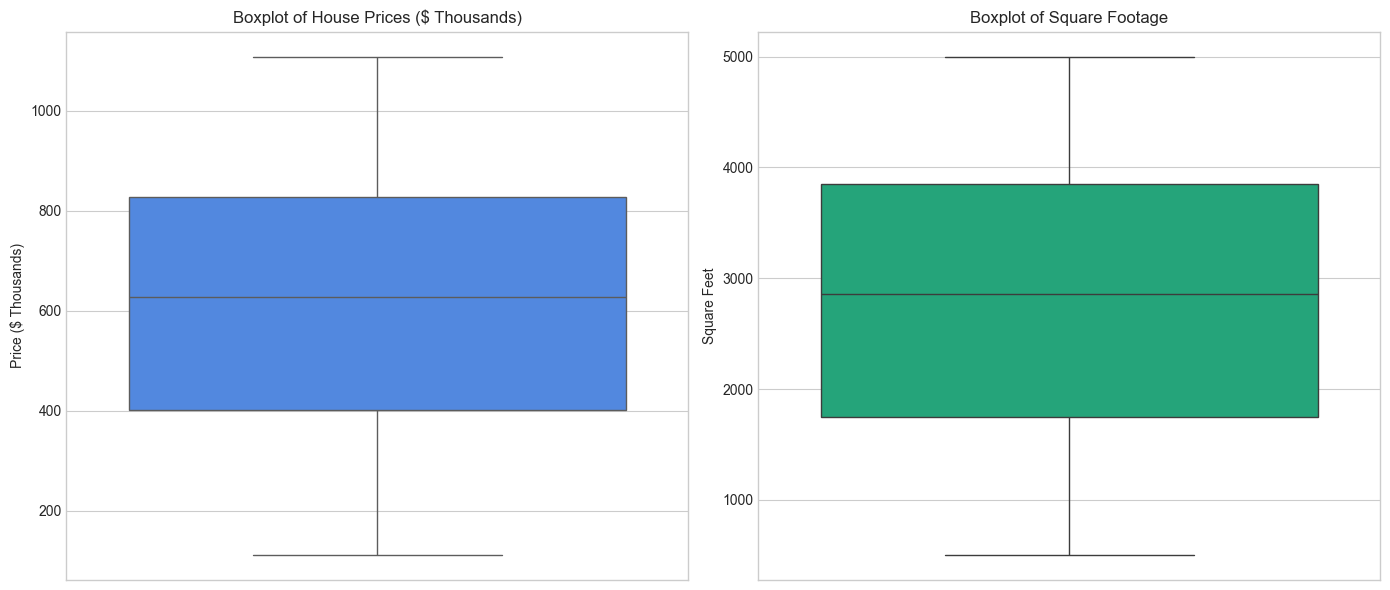

In [3]:
# Section 8 - 11: Data Cleaning & Integrity Analysis
print("[*] Missing Values Count per Feature:")
print(df.isnull().sum())

print(f"\n[*] Total Duplicate Rows: {df.duplicated().sum()}")

# Outlier Boxplots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['House_Price'] / 1000, color='#3B82F6')
plt.title("Boxplot of House Prices ($ Thousands)")
plt.ylabel("Price ($ Thousands)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Square_Footage'], color='#10B981')
plt.title("Boxplot of Square Footage")
plt.ylabel("Square Feet")
plt.tight_layout()
plt.show()

C:\Users\vinay\AppData\Local\Temp\ipykernel_19852\226616897.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Neighborhood_Quality', y=df['House_Price']/1000, ax=axes[1, 0], palette='Blues')


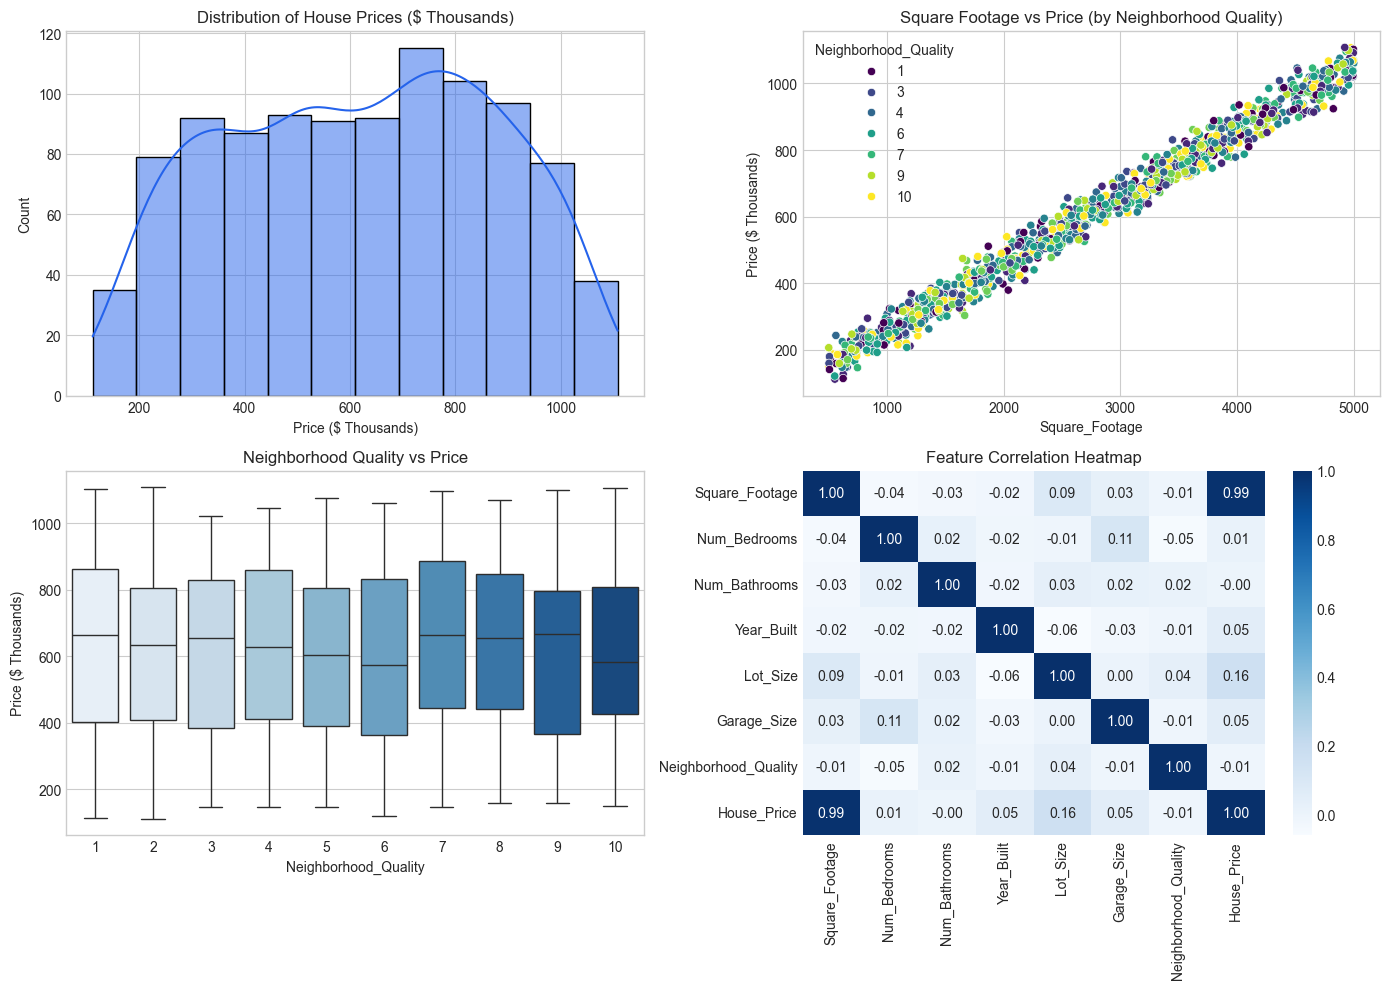

In [4]:
# Section 12: Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Distribution
sns.histplot(df['House_Price'] / 1000, kde=True, ax=axes[0, 0], color='#2563EB')
axes[0, 0].set_title("Distribution of House Prices ($ Thousands)")
axes[0, 0].set_xlabel("Price ($ Thousands)")

# 2. Square Footage vs Price
sns.scatterplot(data=df, x='Square_Footage', y=df['House_Price']/1000, hue='Neighborhood_Quality', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title("Square Footage vs Price (by Neighborhood Quality)")
axes[0, 1].set_ylabel("Price ($ Thousands)")

# 3. Neighborhood Quality vs Price
sns.boxplot(data=df, x='Neighborhood_Quality', y=df['House_Price']/1000, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title("Neighborhood Quality vs Price")
axes[1, 0].set_ylabel("Price ($ Thousands)")

# 4. Feature Correlation Matrix
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [5]:
# Section 13 - 15: Feature Selection, Engineering & Train-Test Split
feature_cols = [
    'Square_Footage', 
    'Num_Bedrooms', 
    'Num_Bathrooms', 
    'Year_Built', 
    'Lot_Size', 
    'Garage_Size',
    'Neighborhood_Quality'
]
target_col = 'House_Price'

X = df[feature_cols]
y = df[target_col]

# Train-Test Split (80% Train, 20% Test, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"[*] Training set shape: {X_train.shape}")
print(f"[*] Test set shape: {X_test.shape}")

[*] Training set shape: (800, 7)
[*] Test set shape: (200, 7)


In [6]:
# Section 16 & 17: Model Training & Evaluation
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train Model
pipeline.fit(X_train, y_train)

# Model Evaluation
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("MODEL EVALUATION RESULTS (TEST SET):")
print(f"   R² Score (Accuracy) : {r2:.4f}")
print(f"   MAE                 : ${mae:,.2f}")
print(f"   RMSE                : ${rmse:,.2f}")
print("=" * 50)

MODEL EVALUATION RESULTS (TEST SET):
   R² Score (Accuracy) : 0.9984
   MAE                 : $8,174.58
   RMSE                : $10,071.48


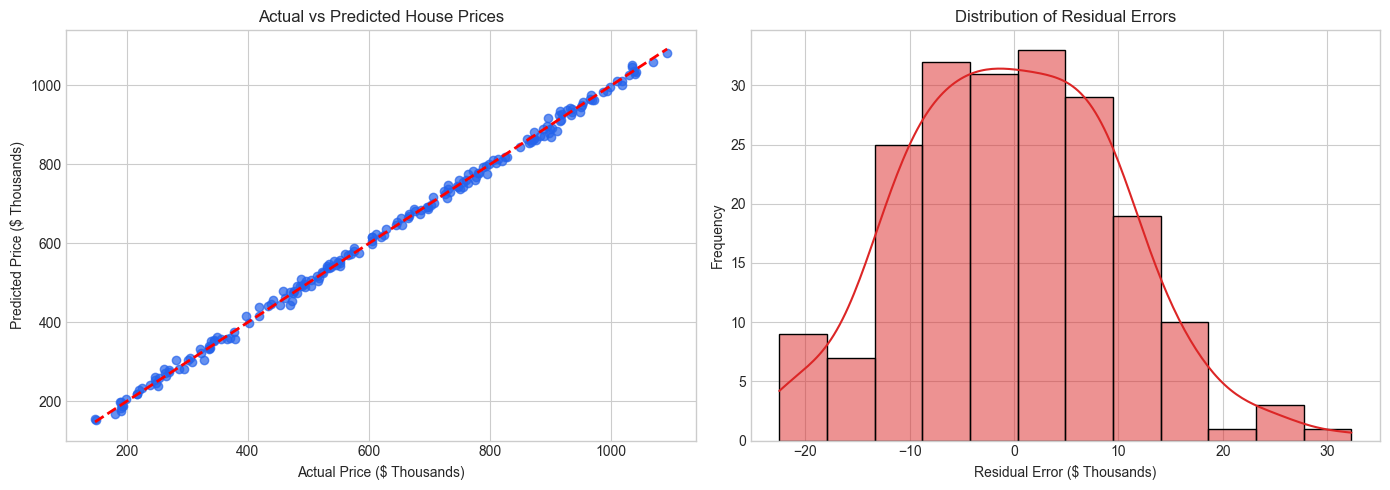

In [7]:
# Section 18 - 20: Actual vs Predicted & Residual Analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Scatter Plot
axes[0].scatter(y_test / 1000, y_pred / 1000, alpha=0.7, color='#2563EB')
axes[0].plot([y_test.min()/1000, y_test.max()/1000], [y_test.min()/1000, y_test.max()/1000], 'r--', lw=2)
axes[0].set_xlabel("Actual Price ($ Thousands)")
axes[0].set_ylabel("Predicted Price ($ Thousands)")
axes[0].set_title("Actual vs Predicted House Prices")

# Residuals Histogram
sns.histplot(residuals / 1000, kde=True, ax=axes[1], color='#DC2626')
axes[1].set_xlabel("Residual Error ($ Thousands)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residual Errors")

plt.tight_layout()
plt.show()

In [8]:
# Section 21 & 22: Model Persistence & Final Validation
os.makedirs("models", exist_ok=True)
joblib.dump(pipeline, os.path.join("models", "model.pkl"))
joblib.dump(pipeline, "model.pkl")
print("[*] Model saved successfully to 'models/model.pkl' and 'model.pkl'.")

# Perform sample inference
sample_data = pd.DataFrame([{
    'Square_Footage': 2500,
    'Num_Bedrooms': 3,
    'Num_Bathrooms': 2,
    'Year_Built': 2005,
    'Lot_Size': 3.5,
    'Garage_Size': 2,
    'Neighborhood_Quality': 8
}])
predicted_val = pipeline.predict(sample_data)[0]
print(f"[*] Sample Prediction for 2500 sq.ft property: ${predicted_val:,.2f}")

[*] Model saved successfully to 'models/model.pkl' and 'model.pkl'.
[*] Sample Prediction for 2500 sq.ft property: $590,661.89
